# AIME quartile delta analysis

This notebook compares each dataset index's eval solve rate against its initial pass@1 baseline from the AIME quartiles dataset.

Expected CSV columns:
- `dataset_index`
- `id`
- `name`
- `solve_rate`

If your CSV does not have a `step` column, the notebook extracts it from `name` when it contains `step_XXXX`.

In [7]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display

from open_instruct.grpo_utils import estimate_pass_at_k

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATASET_REPO = "mnoukhov/aime2024-25-rlvr-olmo3-7b-base-pass64-quartiles"
DATASET_SPLIT = "test"
EVAL_CSV_PATH = Path("../notebooks/wandb_export.csv")


In [3]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower()).strip("_") for col in df.columns]
    return df


def parse_step_from_name(name: str) -> int:
    match = re.search(r"step_(\d+)", str(name))
    if match is None:
        raise ValueError(f"Could not parse a step from {name!r}")
    return int(match.group(1))


def load_baseline(dataset_repo: str, split: str) -> pd.DataFrame:
    ds = load_dataset(dataset_repo, split=split)
    df = normalize_columns(ds.to_pandas())

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            df["dataset_index"] = np.arange(len(df), dtype=int)

    if "pass_count" not in df.columns:
        if "pass_rate" not in df.columns:
            raise ValueError("The baseline dataset needs pass_count or pass_rate.")
        df["pass_count"] = df["pass_rate"].map(lambda value: int(str(value).split("/", 1)[0]))

    required_columns = {"dataset_index", "dataset", "num_samples", "pass_count"}
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["num_samples"] = pd.to_numeric(df["num_samples"], errors="raise").astype(int)
    df["pass_count"] = pd.to_numeric(df["pass_count"], errors="raise").astype(int)
    df["initial_pass_at_1"] = [
        estimate_pass_at_k(num_samples=int(num_samples), num_correct=int(pass_count), k=1)
        for pass_count, num_samples in zip(df["pass_count"], df["num_samples"])
    ]
    df["quartile"] = df["dataset"].astype(str).str.extract(r"quartile(\d+)").astype("Int64")

    return df[["dataset_index", "dataset", "quartile", "pass_count", "num_samples", "initial_pass_at_1"]]


def load_eval_csv(path: Path) -> pd.DataFrame:
    df = normalize_columns(pd.read_csv(path))

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            raise ValueError("The eval CSV needs a dataset_index column.")

    if "solve_rate" not in df.columns:
        if "pass_rate" in df.columns:
            df = df.rename(columns={"pass_rate": "solve_rate"})
        else:
            raise ValueError("The eval CSV needs a solve_rate column.")

    if "step" not in df.columns:
        if "name" not in df.columns:
            raise ValueError("The eval CSV needs either a step column or a name column containing step_XXXX.")
        df["step"] = df["name"].map(parse_step_from_name)

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["solve_rate"] = pd.to_numeric(df["solve_rate"], errors="raise")
    df["step"] = pd.to_numeric(df["step"], errors="raise").astype(int)

    return df


In [2]:
baseline = load_baseline(DATASET_REPO, DATASET_SPLIT)
eval_df = load_eval_csv(EVAL_CSV_PATH)

merged = eval_df.merge(
    baseline,
    on="dataset_index",
    how="left",
    validate="many_to_one",
)
merged["delta_vs_initial_pass_at_1"] = merged["solve_rate"] - merged["initial_pass_at_1"]
merged = merged.sort_values(["quartile", "dataset_index", "step"]).reset_index(drop=True)

display(merged.head())
display(merged[["step", "delta_vs_initial_pass_at_1"]].groupby("step", as_index=False).mean())


NameError: name 'load_baseline' is not defined

In [3]:
eval_df

NameError: name 'eval_df' is not defined

## Delta over steps

The first plot shows the mean delta across all dataset indices. The second breaks that mean delta out by quartile.

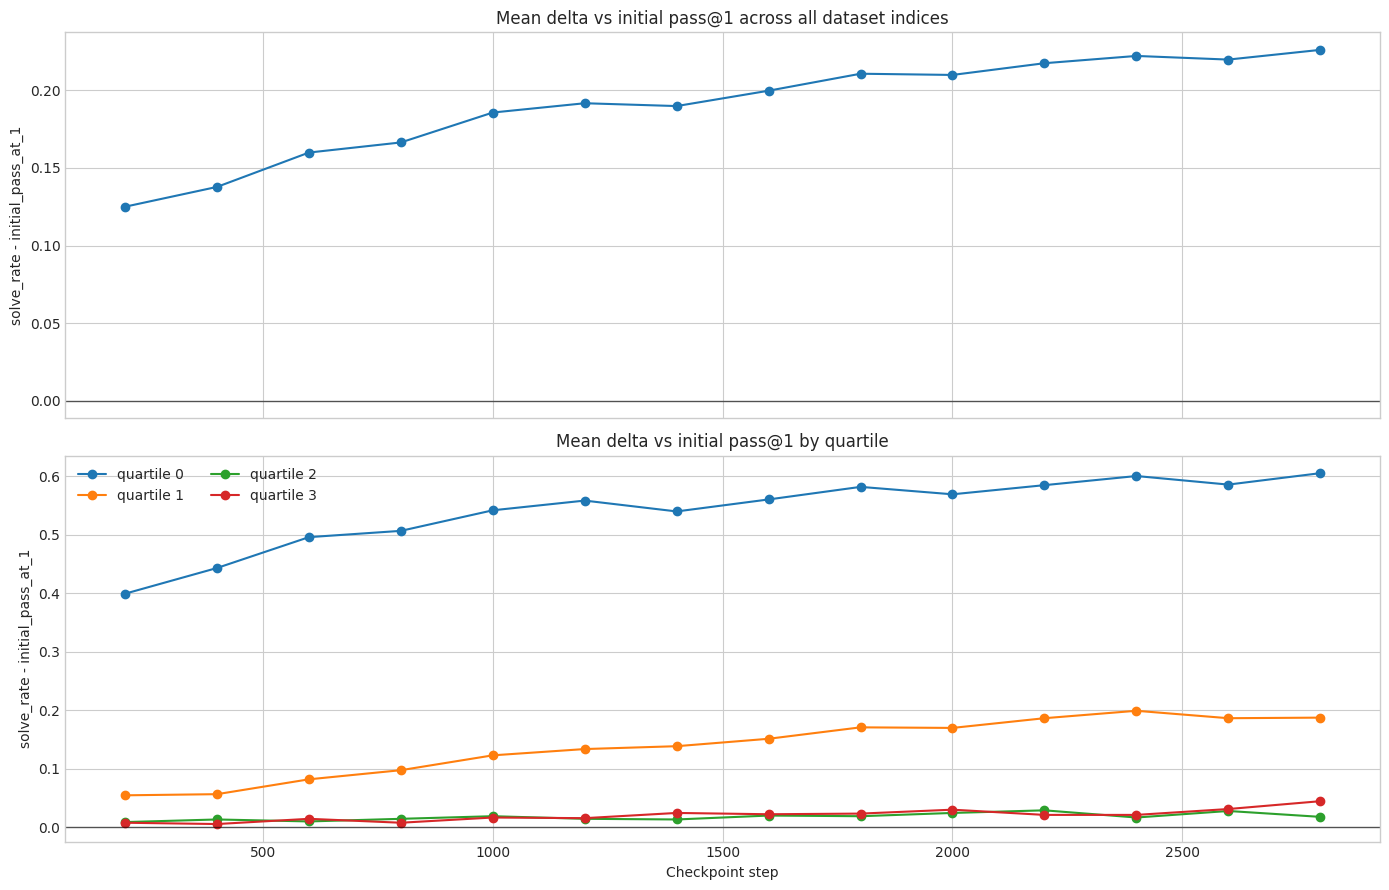

In [9]:
step_summary = merged.groupby("step", as_index=False)["delta_vs_initial_pass_at_1"].mean()
quartile_summary = (
    merged.groupby(["step", "quartile"], as_index=False)["delta_vs_initial_pass_at_1"].mean().sort_values(["quartile", "step"])
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(step_summary["step"], step_summary["delta_vs_initial_pass_at_1"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_title("Mean delta vs initial pass@1 across all dataset indices")
axes[0].set_ylabel("solve_rate - initial_pass_at_1")

for quartile, subset in quartile_summary.groupby("quartile"):
    axes[1].plot(subset["step"], subset["delta_vs_initial_pass_at_1"], marker="o", label=f"quartile {int(quartile)}")

axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[1].set_title("Mean delta vs initial pass@1 by quartile")
axes[1].set_xlabel("Checkpoint step")
axes[1].set_ylabel("solve_rate - initial_pass_at_1")
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()


## Heatmap by dataset index

This is the most direct view of the difference between the initial baseline and each eval checkpoint for every dataset index.

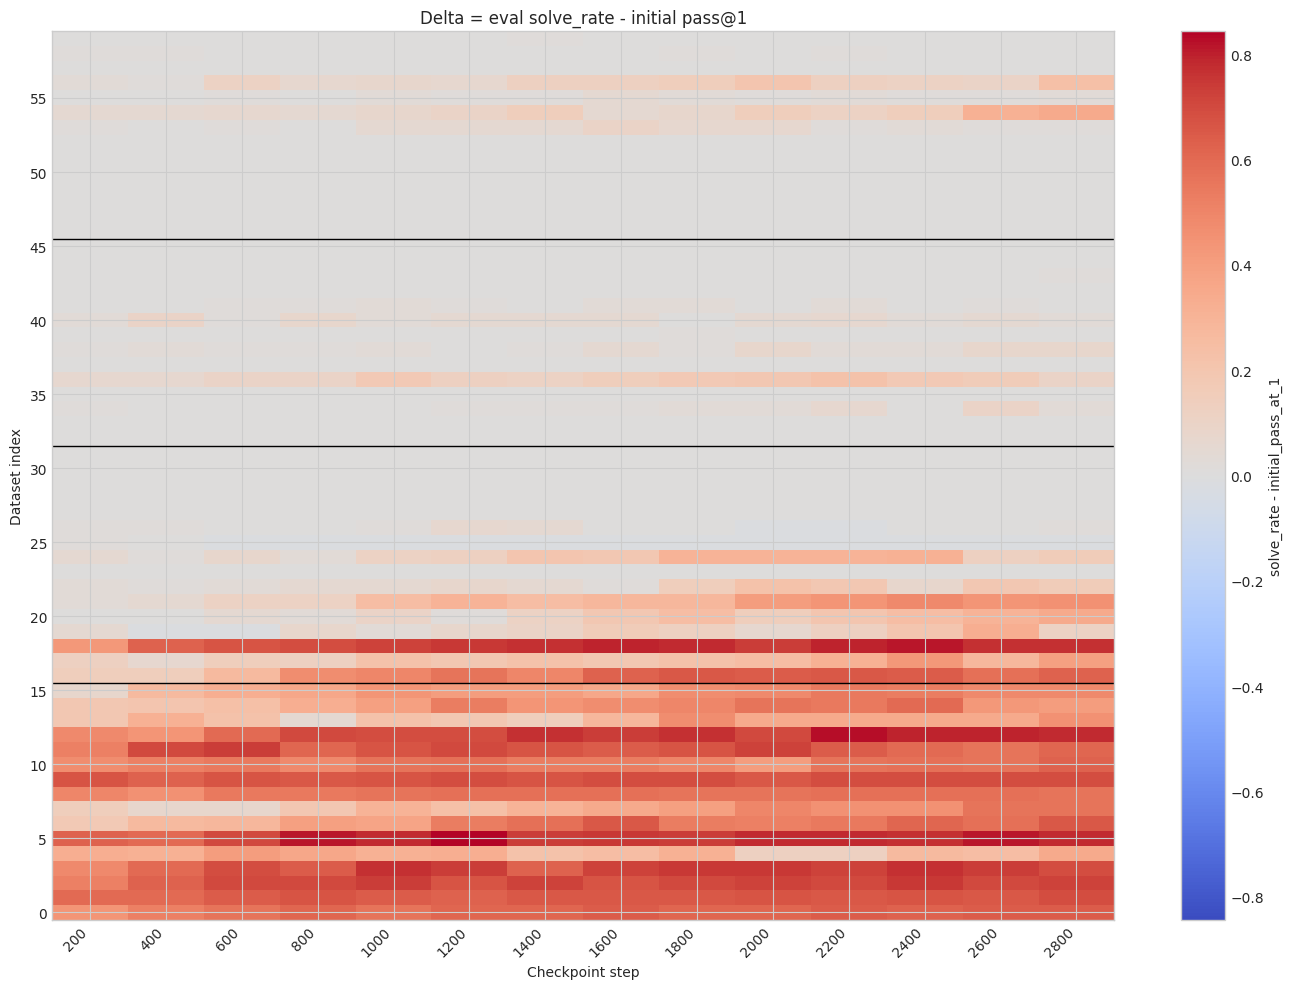

In [17]:
row_order = baseline.sort_values(["quartile", "dataset_index"])["dataset_index"].tolist()
heatmap = (
    merged.pivot_table(
        index="dataset_index",
        columns="step",
        values="delta_vs_initial_pass_at_1",
        aggfunc="mean",
    )
    .reindex(row_order)
    .sort_index(axis=1)
)

heatmap_values = heatmap.to_numpy(dtype=float)
max_abs = float(np.nanmax(np.abs(heatmap_values))) if np.isfinite(heatmap_values).any() else 1.0
max_abs = max(max_abs, 1e-9)

fig, ax = plt.subplots(figsize=(14, 10))
image = ax.imshow(
    heatmap_values,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
)

ax.set_title("Delta = eval solve_rate - initial pass@1")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("Dataset index")
ax.set_xticks(np.arange(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns.tolist(), rotation=45, ha="right")

tick_positions = np.arange(0, len(heatmap.index), max(1, len(heatmap.index) // 12))
ax.set_yticks(tick_positions)
ax.set_yticklabels([int(heatmap.index[i]) for i in tick_positions])

quartile_sizes = baseline.sort_values(["quartile", "dataset_index"]).groupby("quartile").size().tolist()
boundary = 0
for size in quartile_sizes[:-1]:
    boundary += size
    ax.axhline(boundary - 0.5, color="black", linewidth=1)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("solve_rate - initial_pass_at_1")
plt.tight_layout()
plt.show()


## Inspect a single dataset index

Set `DATASET_INDEX_TO_PLOT` to any row index you want to inspect in detail.

,step,dataset_index,dataset,solve_rate,initial_pass_at_1,delta_vs_initial_pass_at_1,name
0,200,0,math_aime_quartile0,0.781250,0.34375,0.437500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
1,400,0,math_aime_quartile0,0.859375,0.34375,0.515625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
2,600,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
3,800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
4,1000,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
5,1200,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
6,1400,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
7,1600,0,math_aime_quartile0,0.984375,0.34375,0.640625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
8,1800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
9,2000,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...


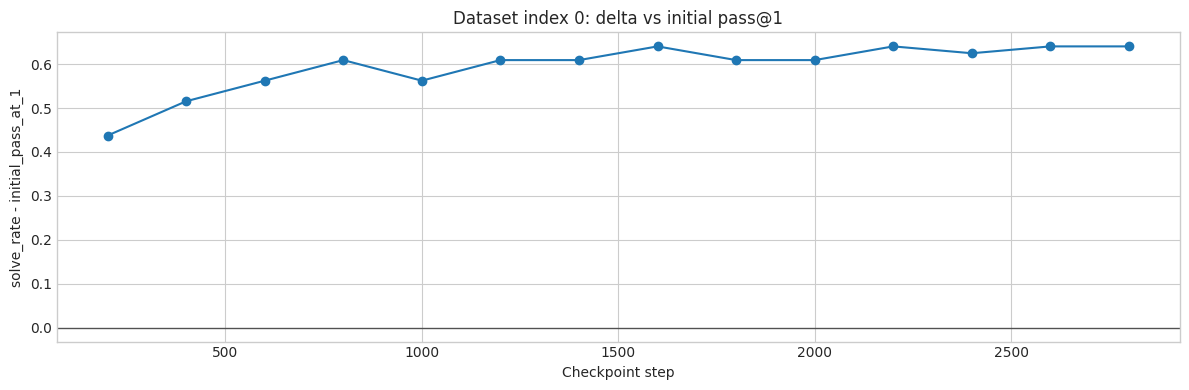

In [11]:
DATASET_INDEX_TO_PLOT = 0

one_index = merged[merged["dataset_index"] == DATASET_INDEX_TO_PLOT].sort_values("step").copy()
display(
    one_index[
        ["step", "dataset_index", "dataset", "solve_rate", "initial_pass_at_1", "delta_vs_initial_pass_at_1", "name"]
    ]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_index["step"], one_index["delta_vs_initial_pass_at_1"], marker="o")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title(f"Dataset index {DATASET_INDEX_TO_PLOT}: delta vs initial pass@1")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("solve_rate - initial_pass_at_1")
plt.tight_layout()
plt.show()
